# Grad-TTS: A Diffusion Probabilistic Model for Text-to-Speech

Official implementation of the Grad-TTS model based on Diffusion Probabilistic Models. For all details check out our paper accepted to ICML 2021 via [this](https://arxiv.org/abs/2105.06337) link.

You can listen to the samples on our demo page via [this](https://grad-tts.github.io/) link.

You can access Google Colab demo notebook via [this](https://colab.research.google.com/drive/1YNrXtkJQKcYDmIYJeyX8s5eXxB4zgpZI?usp=sharing) link.

**Authors**: Vadim Popov\*, Ivan Vovk\*, Vladimir Gogoryan, Tasnima Sadekova, Mikhail Kudinov.

<sup>\*Equal contribution.</sup>

**Note**: for fast synthesis prefer running inference on GPU device.

In [1]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
import argparse
import json
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm
from scipy.io.wavfile import write

import torch

# For Grad-TTS
import params
from model import GradTTS
from text import text_to_sequence, cmudict
from text.symbols import symbols
from utils import intersperse

# For HiFi-GAN
import sys
sys.path.append('./hifi-gan/')
from env import AttrDict
from models import Generator as HiFiGAN

In [3]:
N_SPKS = 247  # 247 for Libri-TTS model and 1 for single speaker (LJSpeech)

In [4]:
generator = GradTTS(len(symbols)+1, N_SPKS, params.spk_emb_dim,
                    params.n_enc_channels, params.filter_channels,
                    params.filter_channels_dp, params.n_heads, params.n_enc_layers,
                    params.enc_kernel, params.enc_dropout, params.window_size,
                    params.n_feats, params.dec_dim, params.beta_min, params.beta_max,
                    pe_scale=1000)  # pe_scale=1 for `grad-tts-old.pt`
generator.load_state_dict(torch.load('./checkpts/grad-tts-libri-tts.pt', map_location=lambda loc, storage: loc))
_ = generator.cpu().eval() # cpu instead of cuda()
print(f'Number of parameters: {generator.nparams}')

cmu = cmudict.CMUDict('./resources/cmu_dictionary')

Number of parameters: 14888680


In [5]:
with open('./checkpts/hifigan-config.json') as f:
    h = AttrDict(json.load(f))
hifigan = HiFiGAN(h)
hifigan.load_state_dict(torch.load('./checkpts/hifigan.pt', map_location=lambda loc, storage: loc)['generator'])
_ = hifigan.cpu().eval() # cpu instead of cuda()
hifigan.remove_weight_norm()
%matplotlib inline

/opt/anaconda3/envs/LabAML/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


Removing weight norm...


In [6]:
text = "I am studying Artificial Intelligence."

In [7]:
x = torch.LongTensor(intersperse(text_to_sequence(text, dictionary=cmu), len(symbols))).cpu()[None] # cpu instead of cuda()
x_lengths = torch.LongTensor([x.shape[-1]]).cpu() # cpu instead of cuda()
x.shape, x_lengths

(torch.Size([1, 75]), tensor([75]))

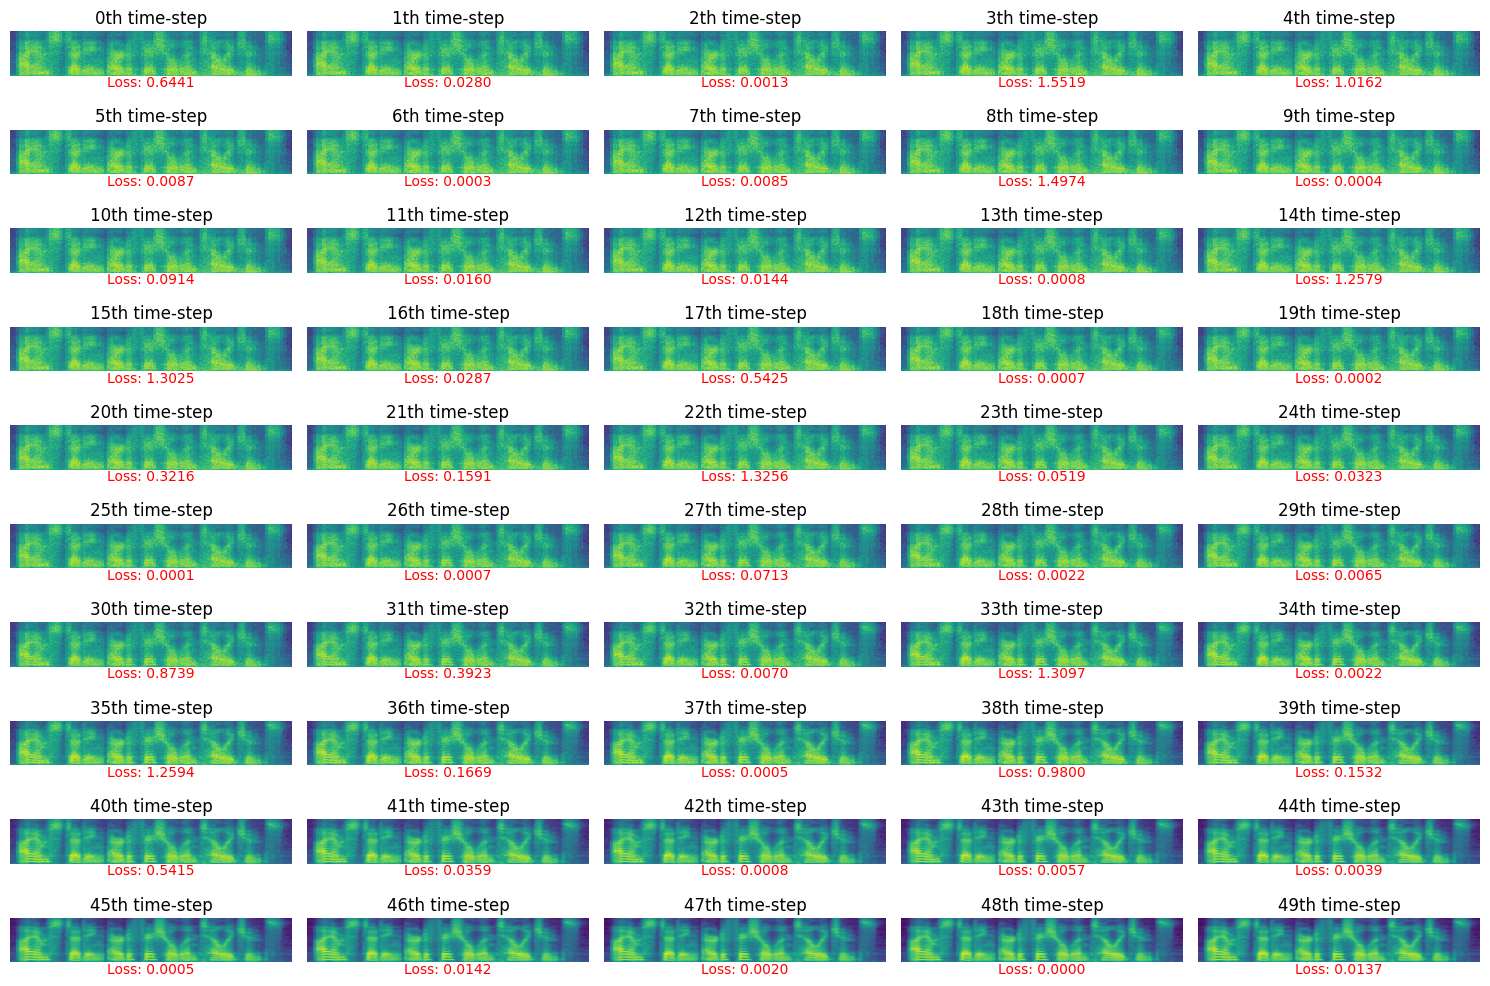

Grad-TTS RTF: 5.829499283854167


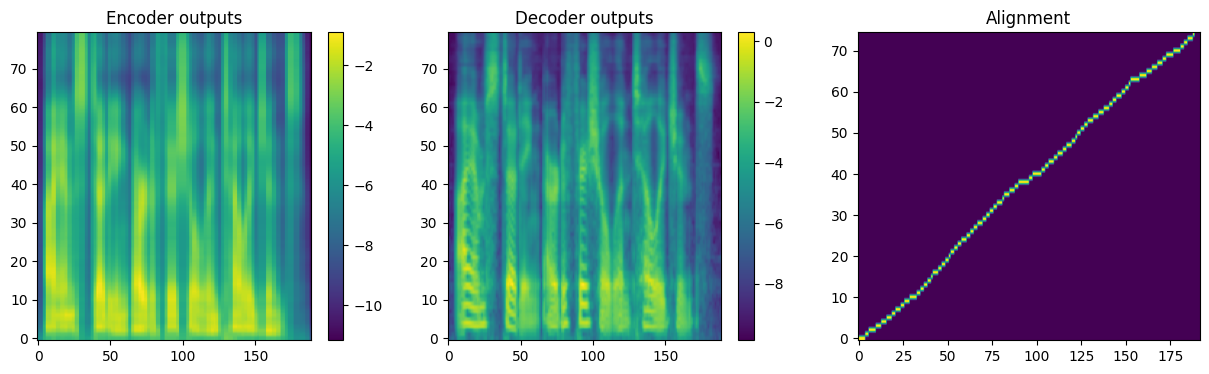

In [8]:
%matplotlib inline

t = dt.datetime.now()
y_enc, y_dec, attn, y_dec_list, loss_list = generator.forward(x, x_lengths, n_timesteps=50, temperature=1.3,
                                       stoc=False, spk=None if N_SPKS==1 else torch.LongTensor([15]).cpu(), # cpu instead of cuda()
                                       length_scale=0.91)
t = (dt.datetime.now() - t).total_seconds()

# 예시: y_dec_list가 50개의 이미지 리스트라고 가정
num_plots = len(y_dec_list)

# 10행 5열로 서브플롯을 설정 (50개의 그래프에 대해 적당히 나눔)
ncols = 5
nrows = (num_plots // ncols) + (num_plots % ncols > 0)  # 나머지가 있을 경우 한 줄 추가

# 서브플롯 생성
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 10))

# 그래프를 채우기
for i in range(num_plots):
    row = i // ncols  # 몇 번째 행인지
    col = i % ncols   # 몇 번째 열인지
    ax = axes[row, col]  # 해당 위치의 서브플롯을 선택

    # 해당 위치에 그래프를 그림
    ax.imshow(y_dec_list[i].cpu().squeeze(), aspect='auto', origin='lower')
    ax.set_title(f'{i}th time-step')
    ax.axis('off')  # 축 숨기기 (필요한 경우)

    # loss가 튜플이면 첫 번째 값만 가져오기
    loss_value = loss_list[i][0] if isinstance(loss_list[i], tuple) else loss_list[i]

    # 각 피규어 아래에 loss 값을 텍스트로 추가
    ax.text(0.5, -0.15, f'Loss: {loss_value:.4f}', ha='center', va='center', 
            transform=ax.transAxes, fontsize=10, color='red')


# 나머지 빈 서브플롯 비우기
for j in range(num_plots, nrows * ncols):
    row = j // ncols
    col = j % ncols
    axes[row, col].axis('off')  # 빈 자리는 축을 숨김

plt.tight_layout()  # 자동으로 레이아웃을 조정하여 겹치지 않게 함
plt.show()


print(f'Grad-TTS RTF: {t * 22050 / (y_dec.shape[-1] * 256)}')

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title('Encoder outputs')
plt.imshow(y_enc.cpu().squeeze(), aspect='auto', origin='lower')
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title('Decoder outputs')
plt.imshow(y_dec.cpu().squeeze(), aspect='auto', origin='lower')
plt.colorbar()
plt.subplot(1, 3, 3)
plt.title('Alignment')
plt.imshow(attn.cpu().squeeze(), aspect='auto', origin='lower');

In [9]:
with torch.no_grad():
    audio = hifigan.forward(y_dec).cpu().squeeze().clamp(-1, 1)
ipd.display(ipd.Audio(audio, rate=22050))

In [10]:
audio_numpy = audio.numpy()
write(f'./out/sample_3.wav', 22050, (audio_numpy * 32767).astype(np.int16))